In [10]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [16]:
poly = PolynomialFeatures(degree=2)
x_train = [1, 2, 3,]
x_train_poly = poly.fit_transform(np.array(x_train).reshape(-1, 1))
x_train_poly

array([[1., 1., 1.],
       [1., 2., 4.],
       [1., 3., 9.]])

PART 1: ORIGINAL DATA

First 5 rows of original data:
X values        y values
   0.000  →       54.67
   0.101  →       -8.74
   0.202  →       69.91
   0.303  →      157.51
   0.404  →      -18.14


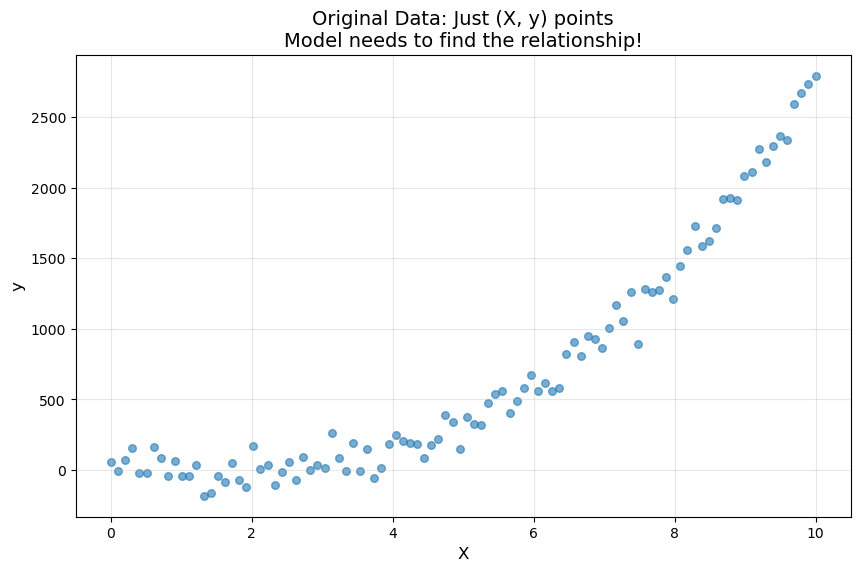


PART 2: POLYNOMIAL TRANSFORMATION

Example: X = 5.0

Transformations for different degrees:

Degree 1:
  Features: ['1', 'x']
  Values:   [1. 5.]

Degree 2:
  Features: ['1', 'x', 'x^2']
  Values:   [ 1.  5. 25.]

Degree 3:
  Features: ['1', 'x', 'x^2', 'x^3']
  Values:   [  1.   5.  25. 125.]

----------------------------------------------------------------------
First 5 rows transformed with degree=3:
----------------------------------------------------------------------
Original X  →  [1,        x,        x²,       x³]
   0.000  →  [1. 0. 0. 0.]
   0.101  →  [1.         0.1010101  0.01020304 0.00103061]
   0.202  →  [1.         0.2020202  0.04081216 0.00824488]
   0.303  →  [1.         0.3030303  0.09182736 0.02782647]
   0.404  →  [1.         0.4040404  0.16324865 0.06595905]

PART 3: MODEL FITTING

True formula: y = 5 + 1*x - 2*x² + 3*x³ (+ noise)

What each model learns:

Degree 1:
  Intercept (β₀): -576.22
  x      (β_1): 253.28

Degree 2:
  Intercept (β₀): 145.30
  x      (β_1

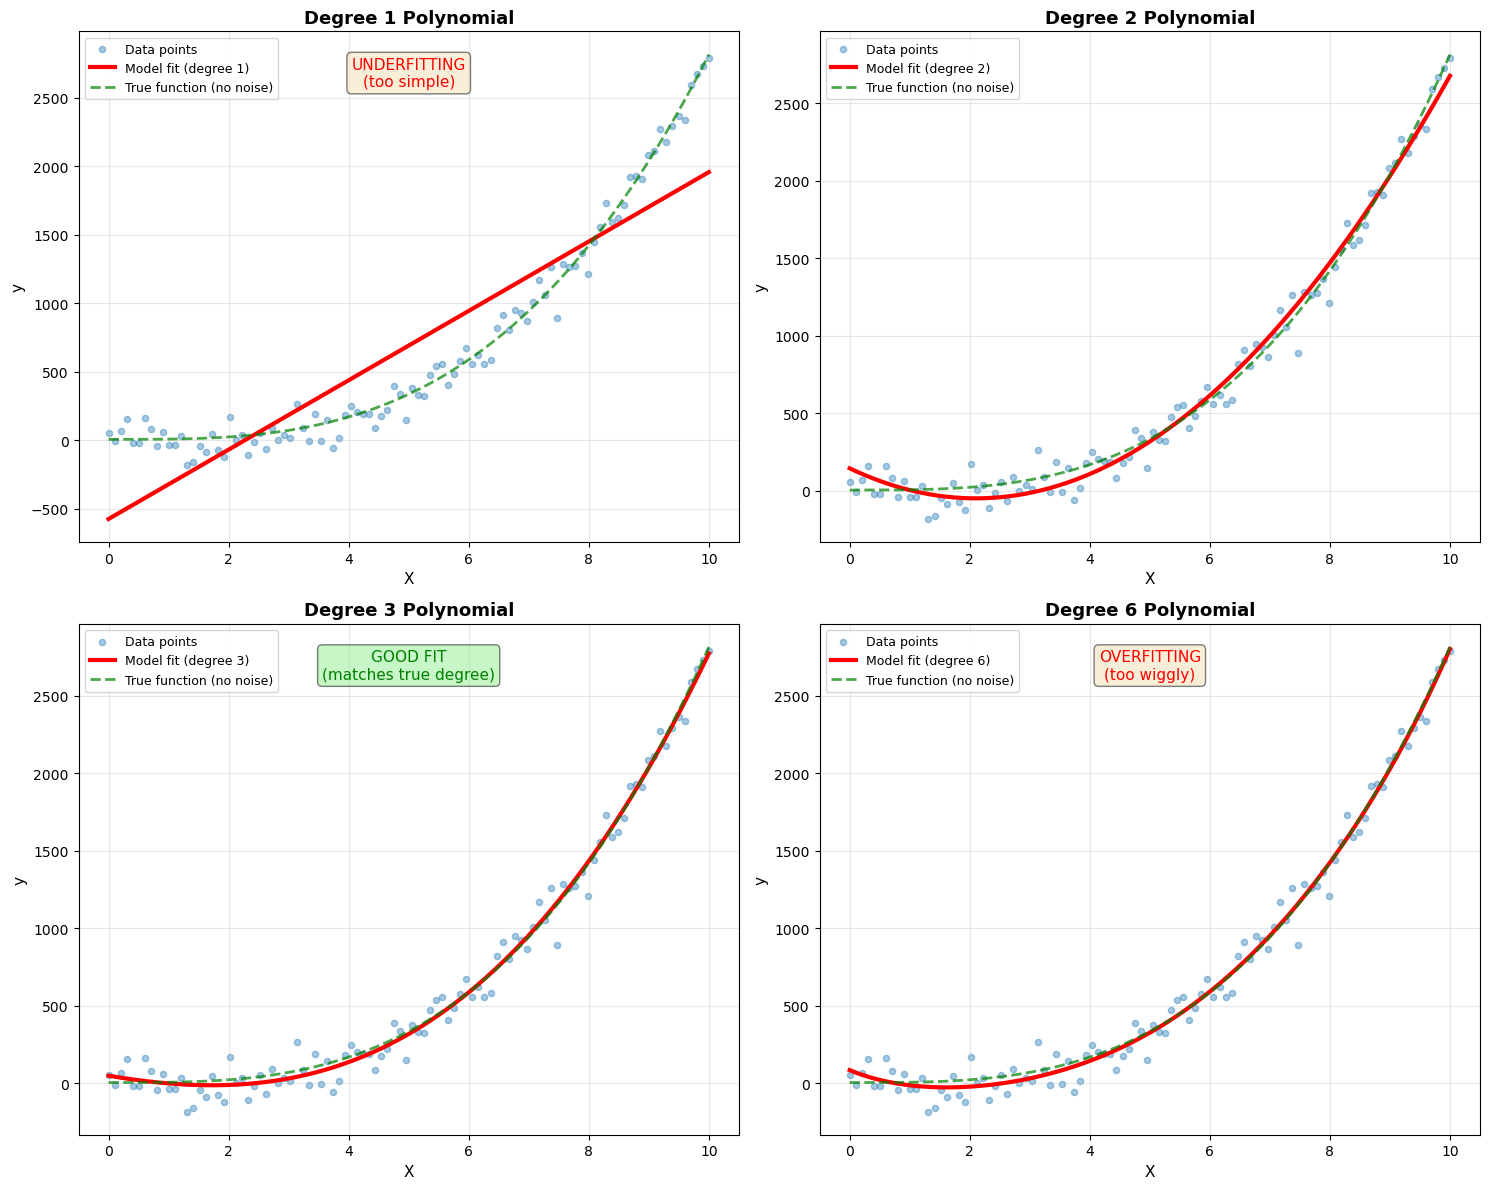

PART 4: HOW THE MODEL DERIVES THE POLYNOMIAL

The model uses LINEAR REGRESSION on the transformed features:

1. We transform X into polynomial features
2. LinearRegression finds coefficients (β) that minimize error
3. It solves: minimize Σ(y - (β₀ + β₁*x + β₂*x² + β₃*x³))²

Compare learned vs true coefficients (for degree 3):
----------------------------------------------------------------------
Term       True Value      Learned Value   Difference
----------------------------------------------------------------------
Constant   5.00            49.30           44.30
x¹         1.00            -65.87          66.87
x²         -2.00           14.04           16.04
x³         3.00            1.98            1.02

Note: Differences are due to the random noise we added!
The model successfully 'discovered' the polynomial relationship!


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Generate data
np.random.seed(42)
X = np.linspace(0, 10, 100).reshape(-1, 1)
y = 3 * X.squeeze()**3 - 2 * X.squeeze()**2 + X.squeeze() + 5 + np.random.randn(100) * 100

# =============================================================================
# PART 1: ORIGINAL DATA
# =============================================================================
print("="*70)
print("PART 1: ORIGINAL DATA")
print("="*70)
print("\nFirst 5 rows of original data:")
print("X values        y values")
for i in range(5):
    print(f"{X[i,0]:8.3f}  →  {y[i]:10.2f}")

plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.6, s=30)
plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Original Data: Just (X, y) points\nModel needs to find the relationship!', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

# =============================================================================
# PART 2: POLYNOMIAL TRANSFORMATION
# =============================================================================
print("\n" + "="*70)
print("PART 2: POLYNOMIAL TRANSFORMATION")
print("="*70)

# Show transformation for a single example
example_x = np.array([[5.0]])
print(f"\nExample: X = {example_x[0,0]}")
print("\nTransformations for different degrees:")

for deg in [1, 2, 3]:
    poly = PolynomialFeatures(degree=deg)
    x_transformed = poly.fit_transform(example_x)
    feature_names = poly.get_feature_names_out(['x'])

    print(f"\nDegree {deg}:")
    print(f"  Features: {list(feature_names)}")
    print(f"  Values:   {x_transformed[0]}")

# Visualize transformation for first 5 data points
print("\n" + "-"*70)
print("First 5 rows transformed with degree=3:")
print("-"*70)
poly3 = PolynomialFeatures(degree=3)
X_poly3 = poly3.fit_transform(X[:5])
print("Original X  →  [1,        x,        x²,       x³]")
for i in range(5):
    print(f"{X[i,0]:8.3f}  →  {X_poly3[i]}")

# =============================================================================
# PART 3: MODEL FITTING - COMPARING DIFFERENT DEGREES
# =============================================================================
print("\n" + "="*70)
print("PART 3: MODEL FITTING")
print("="*70)
print("\nTrue formula: y = 5 + 1*x - 2*x² + 3*x³ (+ noise)")
print("\nWhat each model learns:\n")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for i, degree in enumerate([1, 2, 3, 6]):
    # Transform the data
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)

    # Fit the model
    model = LinearRegression()
    model.fit(X_poly, y)

    # Print learned coefficients
    feature_names = poly.get_feature_names_out(['x'])
    print(f"Degree {degree}:")
    print(f"  Intercept (β₀): {model.intercept_:.2f}")
    for j, (name, coef) in enumerate(zip(feature_names[1:], model.coef_[1:])):
        print(f"  {name:6s} (β_{j+1}): {coef:.2f}")

    # Create smooth prediction line
    X_plot = np.linspace(0, 10, 300).reshape(-1, 1)
    X_plot_poly = poly.transform(X_plot)
    y_plot = model.predict(X_plot_poly)

    # Plot
    ax = axes[i]
    ax.scatter(X, y, alpha=0.4, s=20, label='Data points')
    ax.plot(X_plot, y_plot, 'r-', linewidth=3, label=f'Model fit (degree {degree})')

    # Add true function for comparison
    y_true = 3 * X_plot.squeeze()**3 - 2 * X_plot.squeeze()**2 + X_plot.squeeze() + 5
    ax.plot(X_plot, y_true, 'g--', linewidth=2, alpha=0.7, label='True function (no noise)')

    ax.set_xlabel('X', fontsize=11)
    ax.set_ylabel('y', fontsize=11)
    ax.set_title(f'Degree {degree} Polynomial', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Add text showing if it's good fit
    if degree == 1:
        ax.text(0.5, 0.95, 'UNDERFITTING\n(too simple)',
                transform=ax.transAxes, fontsize=11, color='red',
                ha='center', va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    elif degree == 3:
        ax.text(0.5, 0.95, 'GOOD FIT\n(matches true degree)',
                transform=ax.transAxes, fontsize=11, color='green',
                ha='center', va='top', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
    elif degree == 6:
        ax.text(0.5, 0.95, 'OVERFITTING\n(too wiggly)',
                transform=ax.transAxes, fontsize=11, color='red',
                ha='center', va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    print()

plt.tight_layout()
plt.show()

# =============================================================================
# PART 4: HOW THE MODEL "DERIVES" THE POLYNOMIAL
# =============================================================================
print("="*70)
print("PART 4: HOW THE MODEL DERIVES THE POLYNOMIAL")
print("="*70)
print("\nThe model uses LINEAR REGRESSION on the transformed features:")
print("\n1. We transform X into polynomial features")
print("2. LinearRegression finds coefficients (β) that minimize error")
print("3. It solves: minimize Σ(y - (β₀ + β₁*x + β₂*x² + β₃*x³))²")
print("\nCompare learned vs true coefficients (for degree 3):")
print("-"*70)

poly3 = PolynomialFeatures(degree=3)
X_poly3 = poly3.fit_transform(X)
model3 = LinearRegression()
model3.fit(X_poly3, y)

comparison = {
    'Constant': (5, model3.intercept_),
    'x¹':       (1, model3.coef_[1]),
    'x²':       (-2, model3.coef_[2]),
    'x³':       (3, model3.coef_[3])
}

print(f"{'Term':<10} {'True Value':<15} {'Learned Value':<15} {'Difference'}")
print("-"*70)
for term, (true_val, learned_val) in comparison.items():
    diff = abs(true_val - learned_val)
    print(f"{term:<10} {true_val:<15.2f} {learned_val:<15.2f} {diff:.2f}")

print("\nNote: Differences are due to the random noise we added!")
print("The model successfully 'discovered' the polynomial relationship!")